# K Q V Matrix Visualization

This notebook visualizes the Query, Key, and Value matrices from transformer attention layers.

## 1. Setup & Imports

In [1]:
import sys
import os
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import get_config, get_weights_file_path
from train import get_model, get_ds, greedy_decode

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/polkadot/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 2. Load Model and Data

In [124]:
# Load config and dataset
config = get_config()
_, val_dataloader, vocab_src, vocab_tgt = get_ds(config)

# Build model
model = get_model(config, vocab_src.get_vocab_size(), vocab_tgt.get_vocab_size()).to(device)

# Load weights (change epoch as needed)
epoch = "00"
model_filename = get_weights_file_path(config, epoch)
print(f"Loading weights from: {model_filename}")

state = torch.load(model_filename, map_location=device)
model.load_state_dict(state['model_state_dict'])
model.eval()
print("Model loaded!")

Loading weights from: weights/tmodel_00.pt
Model loaded!


## 3. Load a Batch

In [88]:
# Get a batch from validation set
batch = next(iter(val_dataloader))

encoder_input = batch["encoder_input"].to(device)
encoder_mask = batch["encoder_mask"].to(device)

# Get token labels
encoder_tokens = [vocab_src.id_to_token(idx) for idx in encoder_input[0].cpu().numpy()]

print(f"Source text: {batch['src_text'][0]}")
print(f"Target text: {batch['tgt_text'][0]}")
print(f"\nFirst 10 tokens: {encoder_tokens[:10]}")

Source text: I _must_ have employment and society.
Target text: Il me faut de l’occupation et de la compagnie.

First 10 tokens: ['[SOS]', 'I', '_must_', 'have', 'employment', 'and', 'society', '.', '[EOS]', '[PAD]']


## 4. Run Forward Pass

This populates the K, Q, V matrices in the attention blocks.

In [118]:
with torch.no_grad():
    encoder_output = model.encode(encoder_input, encoder_mask)
    
print("Forward pass complete! K, Q, V matrices are now populated.")

Forward pass complete! K, Q, V matrices are now populated.


## 5. Extract K, Q, V Function

In [119]:
def retrieve_kqv(source: str, layer: int, head: int):
    """
    Retrieve K, Q, V matrices from a specific attention layer and head.
    
    Args:
        source: 'encoder', 'decoder', or 'cross'
        layer: Layer index (0-5)
        head: Head index (0-7)
    
    Returns:
        Tuple of (K, Q, V) as numpy arrays
    """
    if source == "encoder":
        attn = model.encoder.layers[layer].self_attention_block
    elif source == "decoder":
        attn = model.decoder.layers[layer].self_attention_block
    elif source == "cross":
        attn = model.decoder.layers[layer].cross_attention_block
    else:
        raise ValueError(f"Unknown source: {source}")
    
    # Extract batch 0, specific head
    K = attn.K[0, head].detach().cpu().numpy()
    Q = attn.Q[0, head].detach().cpu().numpy()
    V = attn.V[0, head].detach().cpu().numpy()
    
    return K, Q, V

# Test extraction
K, Q, V = retrieve_kqv("encoder", layer=0, head=0)
print(f"K shape: {K.shape}")
print(f"Q shape: {Q.shape}")
print(f"V shape: {V.shape}")

K shape: (350, 64)
Q shape: (350, 64)
V shape: (350, 64)


In [91]:
print(f"\nFirst 10 tokens: {encoder_tokens[:]}")
for k in K:
    print('  '.join(str(e) for e in k))


First 10 tokens: ['[SOS]', 'I', '_must_', 'have', 'employment', 'and', 'society', '.', '[EOS]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[P

## 6. Visualize K, Q, V as Heatmaps

In [ ]:
%matplotlib qt
# Choose layer and head
LAYER = 0
HEAD = 0
MAX_TOKENS = encoder_tokens.index('[EOS]') - 1 if '[EOS]' in encoder_tokens else -1 # Show first N tokens
print(MAX_TOKENS)

# Extract
K, Q, V = retrieve_kqv("encoder", LAYER, HEAD)

K = K[1: MAX_TOKENS + 1]
Q = Q[1: MAX_TOKENS + 1]
V = V[1: MAX_TOKENS + 1]
word_tokens = encoder_tokens[1: MAX_TOKENS + 1]

# Create figure
plt.rcParams["font.family"] = "serif"
fig, axes = plt.subplots(3, 1, figsize=(34, 20))

tick_positions = [i + 0.5 for i in range(min(MAX_TOKENS, len(word_tokens)))]

# Plot K
sns.heatmap(K[:MAX_TOKENS], ax=axes[0], cmap='viridis', cbar_kws={'label': 'Value'})
axes[0].set_title(rf'$\mathbf{{Key\ Matrix}}$' + f'\nLayer {LAYER}, Head {HEAD} \n({MAX_TOKENS} x 64)')
axes[0].set_xlabel(rf'Embedding Dimension ($d_k=64$)')
axes[0].set_ylabel(f'Input Tokens ({MAX_TOKENS})')
axes[0].set_yticks(tick_positions)
axes[0].set_yticklabels(word_tokens, rotation=0, fontsize=8)

# Plot Q
sns.heatmap(Q[:MAX_TOKENS], ax=axes[1], cmap='viridis', cbar_kws={'label': 'Value'})
axes[1].set_title(rf'$\mathbf{{Query\ Matrix}}$' + f'\nLayer {LAYER}, Head {HEAD} \n({MAX_TOKENS} x 64)')
axes[1].set_xlabel(rf'Embedding Dimension ($d_k=64$)')
axes[1].set_ylabel(f'Input Tokens ({MAX_TOKENS})')
axes[1].set_yticks(range(min(MAX_TOKENS, len(word_tokens))))
axes[1].set_yticklabels(word_tokens, rotation=0, fontsize=8)

# Plot V
sns.heatmap(V[:MAX_TOKENS], ax=axes[2], cmap='viridis', cbar_kws={'label': 'Value'})
axes[2].set_title(rf'$\mathbf{{Value\ Matrix}}$' + f'\nLayer {LAYER}, Head {HEAD} \n({MAX_TOKENS} x 64)')
axes[2].set_xlabel(rf'Embedding Dimension ($d_k=64$)')
axes[2].set_ylabel(f'Input Tokens ({MAX_TOKENS})')
axes[2].set_yticks(range(min(MAX_TOKENS, len(word_tokens))))
axes[2].set_yticklabels(word_tokens, rotation=0, fontsize=8)

plt.tight_layout(pad=15)
plt.ion()
plt.show()

7


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

## 7. Visualize Different Layers/Heads

Interactive exploration:

In [112]:
# =========================
# Section 7: True Isometric Layered Attention
# =========================

%matplotlib qt

import matplotlib.transforms as transforms

LAYER_RANGE = range(0, 6)
HEAD = 0

MAX_TOKENS = encoder_tokens.index('[EOS]') - 1 if '[EOS]' in encoder_tokens else -1
word_tokens = encoder_tokens[1: MAX_TOKENS + 1]

plt.rcParams["font.family"] = "serif"

fig, axes = plt.subplots(3, 1, figsize=(18, 22))

titles = [
    r'$\mathbf{Key\ Matrix\ Stack}$',
    r'$\mathbf{Query\ Matrix\ Stack}$',
    r'$\mathbf{Value\ Matrix\ Stack}$'
]

# --- isometric controls ---
dx = 6       # horizontal shift per layer
dy = -4      # vertical shift per layer
shear_deg = -30  # 🔥 THIS creates isometric angle

for ax_idx, ax in enumerate(axes):

    all_mats = []

    for layer in LAYER_RANGE:
        K, Q, V = retrieve_kqv("encoder", layer, HEAD)
        mat = [K, Q, V][ax_idx]
        mat = mat[1: MAX_TOKENS + 1]
        all_mats.append(mat)

    h, w = all_mats[0].shape

    # Draw back → front
    for i, mat in enumerate(all_mats):

        shift_x = i * dx
        shift_y = i * dy

        # --- base image ---
        im = ax.imshow(
            mat,
            cmap='viridis',
            origin='upper',
            interpolation='nearest',
            aspect='equal',
            extent=[0, w, h, 0],
            zorder=i
        )

        # --- apply isometric transform ---
        trans = (
            transforms.Affine2D()
            .skew_deg(shear_deg, 0)   # 🔥 key step
            .translate(shift_x, shift_y)
            + ax.transData
        )

        im.set_transform(trans)

    # ---- axes from FRONT layer only ----
    front_x = (len(LAYER_RANGE) - 1) * dx
    front_y = (len(LAYER_RANGE) - 1) * dy

    xticks = np.arange(0, w, 10)
    ax.set_xticks(front_x + xticks)
    ax.set_xticklabels(xticks)

    step = max(1, h // 12)
    yticks = np.arange(0, h, step)

    ax.set_yticks(front_y + yticks)
    ax.set_yticklabels([word_tokens[i] for i in yticks], fontsize=8)

    ax.set_xlabel(r'Embedding Dimension ($d_k=64$)')
    ax.set_ylabel('Tokens')

    ax.set_title(
        titles[ax_idx] + f"\nHead {HEAD} Across {len(LAYER_RANGE)} Layers",
        fontsize=16
    )

plt.tight_layout(pad=6)
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

## 8. Compare Multiple Heads

Visualize all 8 heads in a layer:

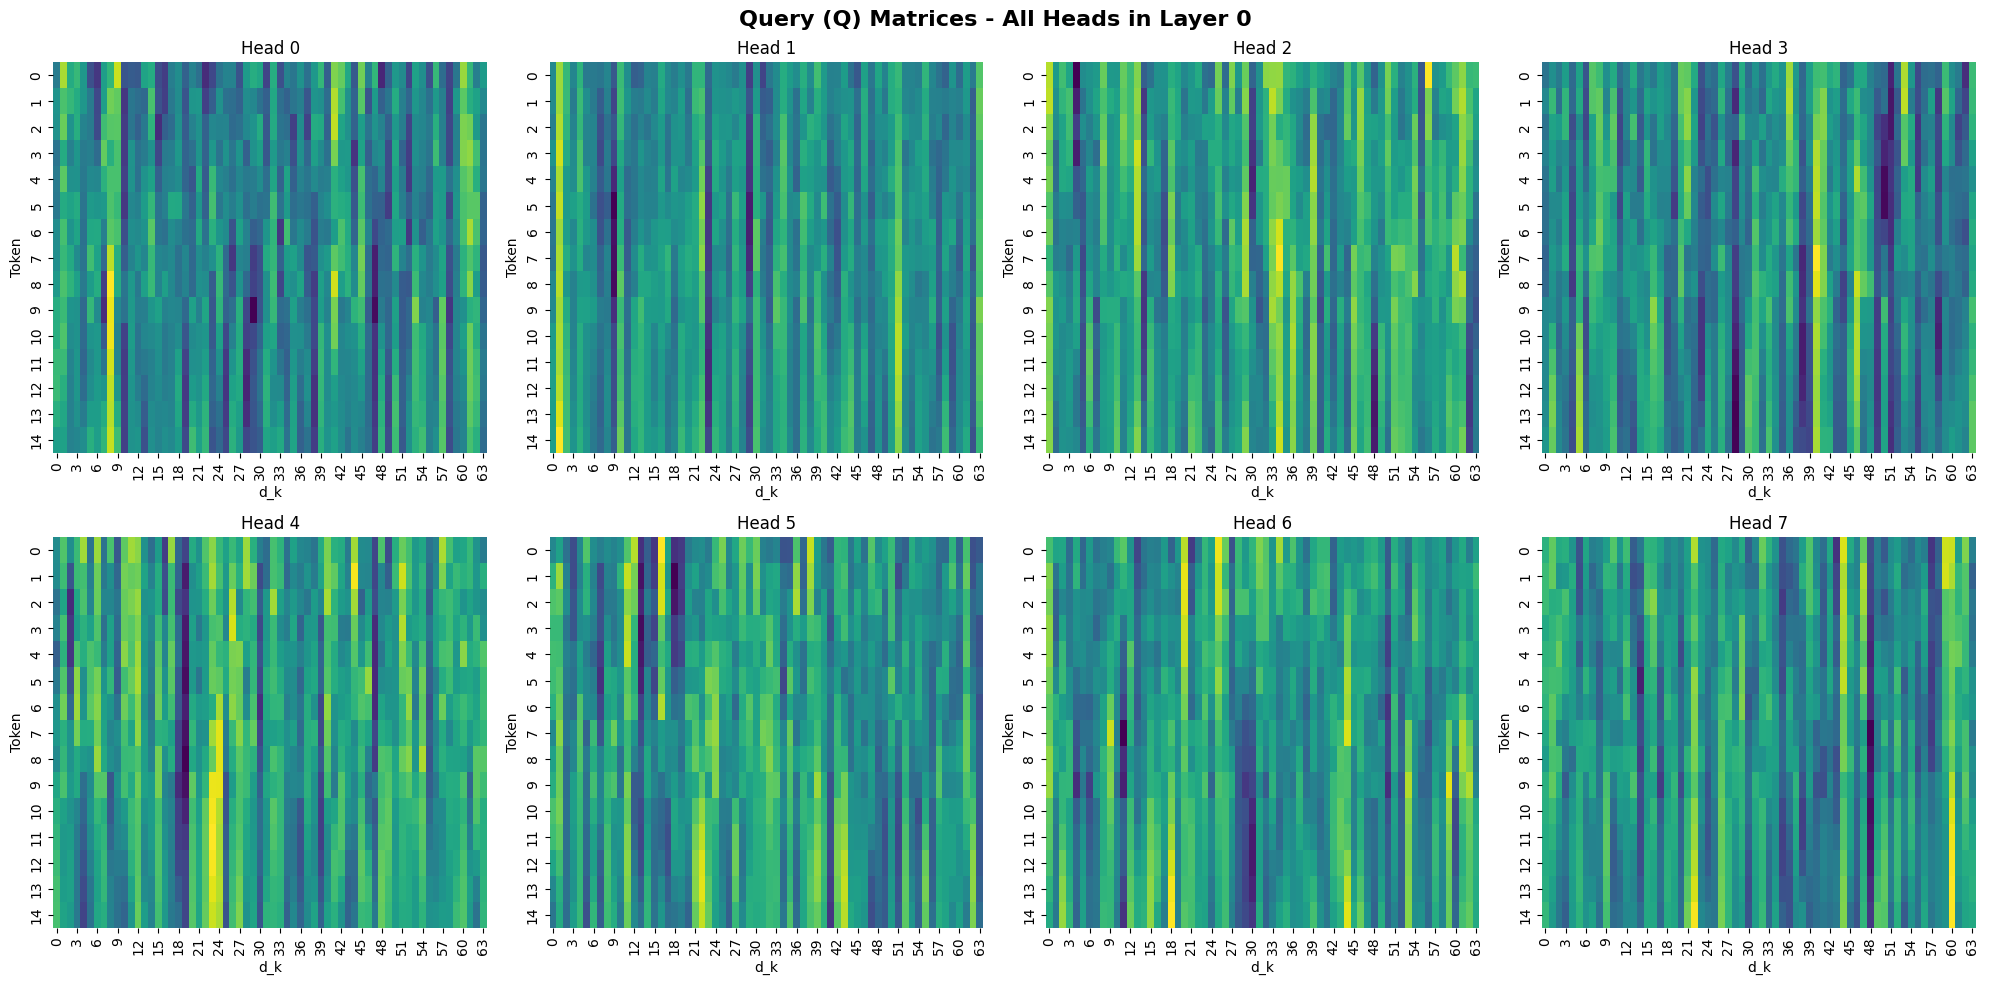

In [17]:
LAYER = 0
NUM_HEADS = 8
max_tokens = 15

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for head in range(NUM_HEADS):
    K, Q, V = retrieve_kqv("encoder", LAYER, head)
    
    # Show Q matrix for each head
    sns.heatmap(Q[:max_tokens], ax=axes[head], cmap='viridis', cbar=False)
    axes[head].set_title(f'Head {head}')
    axes[head].set_xlabel('d_k')
    axes[head].set_ylabel('Token')

plt.suptitle(f'Query (Q) Matrices - All Heads in Layer {LAYER}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()